In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as patches
import squarify
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from pypalettes import load_cmap
from ipywidgets import VBox
import circlify
import textwrap

In [3]:
# Modifiquem algunes configuracions de l'output.
pio.renderers.default = "notebook" # or "vscode", "colab", "browser"
pd.options.display.float_format = "{:,.2f}".format

def show(df):
    format_dict = {}
    
    # 1. Find integer columns and format with 0 decimal places
    int_cols = df.select_dtypes(include=['int64', 'int32']).columns
    for col in int_cols:
        format_dict[col] = "{:,.0f}"
        
    # 2. Find floating columns and format with 2 decimal places
    float_cols = df.select_dtypes(include=['float64', 'float32']).columns
    for col in float_cols:
        format_dict[col] = "{:,.2f}"
        
    # Apply the combined formatting dictionary
    return df.style.format(format_dict)

In [4]:
# Importem les dades
data = pd.read_csv("./Receptes_facturades.csv", 
                  thousands=".", 
                   decimal=",")

C:\Users\cymbe\AppData\Local\Temp\ipykernel_21548\3768193472.py:2: DtypeWarning: Columns (0: codi de la regió sanitària) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("./Receptes_facturades.csv",


In [5]:
# Revisem les primeres 5 files del dataset
data.head()

,any,mes,codi de la regió sanitària,regió sanitària,grup d'edat,sexe,codi del grup ATC nivell 1,grup ATC nivell 1,codi del grup ATC nivell 2,grup ATC nivell 2,codi del grup ATC nivell 3,grup ATC nivell 3,codi del grup ATC nivell 4,grup ATC nivell 4,nombre de receptes,nombre d'envasos,import íntegre,import aportació CatSalut
0,2025,10,61,LLEIDA,0-1 any,Dona,A,TRACTO ALIMENTARIO Y METABOLISMO,A01,PREPARADOS ESTOMATOLOGICOS,A01A,PREPARADOS ESTOMATOLOGICOS,A01AB,Antiinfecciosos y antisepticos para el tratami...,2,2,5.66,3.40
1,2025,10,61,LLEIDA,0-1 any,Dona,A,TRACTO ALIMENTARIO Y METABOLISMO,A02,AGENTES PARA EL TRATAMIENTO DE ALTERACIONES CA...,A02B,AGENTES CONTRA LA ULCERA PEPTICA Y EL REFLUJO ...,A02BC,Inhibidores de la bomba de protones,1,1,17.75,10.65
2,2025,10,61,LLEIDA,0-1 any,Dona,A,TRACTO ALIMENTARIO Y METABOLISMO,A07,"ANTIDIARREICOS, AGENTES ANTIINFLAMATORIOS/ANTI...",A07A,ANTIINFECCIOSOS INTESTINALES,A07AA,Antibioticos,21,21,98.28,63.21
3,2025,10,61,LLEIDA,0-1 any,Dona,A,TRACTO ALIMENTARIO Y METABOLISMO,A07,"ANTIDIARREICOS, AGENTES ANTIINFLAMATORIOS/ANTI...",A07C,ELECTROLITOS CON CARBOHIDRATOS,A07CA,Formulaciones de sales de rehidratacion oral,60,60,207.72,126.84
4,2025,10,61,LLEIDA,0-1 any,Dona,A,TRACTO ALIMENTARIO Y METABOLISMO,A11,VITAMINAS,A11C,"VITAMINAS A Y D, INCLUYENDO COMBINACIONES DE L...",A11CC,Vitamina D y analogos,325,325,"1,597.48","1,013.94"


In [6]:
# Comprovem quantes files tenim i quin tipus de dades hem carregat a cada columna.
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7921921 entries, 0 to 7921920
Data columns (total 18 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   any                         int64  
 1   mes                         int64  
 2   codi de la regió sanitària  object 
 3   regió sanitària             str    
 4   grup d'edat                 str    
 5   sexe                        str    
 6   codi del grup ATC nivell 1  str    
 7   grup ATC nivell 1           str    
 8   codi del grup ATC nivell 2  str    
 9   grup ATC nivell 2           str    
 10  codi del grup ATC nivell 3  str    
 11  grup ATC nivell 3           str    
 12  codi del grup ATC nivell 4  str    
 13  grup ATC nivell 4           str    
 14  nombre de receptes          int64  
 15  nombre d'envasos            int64  
 16  import íntegre              float64
 17  import aportació CatSalut   float64
dtypes: float64(2), int64(4), object(1), str(11)
memory usage: 1.1+ GB


In [7]:
# Comprovem quins son els possibles valors de codi de la regió sanitària, per decidir com tractem l'error de tipus de dades
pd.unique(data["codi de la regió sanitària"])

array([61, 62, 63, 64, 67, 70, 71, 75, '75', '76', '79', 'AL', 'SE', '61',
       76, '62', 79, '63', '64', 78, '78', '67', '71'], dtype=object)

In [8]:
# Evaluem el pes de les dues regions sanitàries amb codis alfabètics
print(
    "Registres amb codis de regió sanitària Altres o Sense Especificar: {:.0f} ({:.2%})".format(
        len(data[data["codi de la regió sanitària"].isin(["SE", "AL"])]),
        len(data[data["codi de la regió sanitària"].isin(["SE", "AL"])])/len(data)
    )
)

# Son menys d'un 2%, així que decidim eliminar-les.
# Creem un dataframe nou per treballar els canvis.
wdata = data.drop(data[data["codi de la regió sanitària"].isin(["SE", "AL"])].index)
len(wdata)

# Convertim el codi de regió a tipus numèric
wdata["codi de la regió sanitària"] = pd.to_numeric(wdata["codi de la regió sanitària"], errors='coerce')

Registres amb codis de regió sanitària Altres o Sense Especificar: 133733 (1.69%)


In [9]:
wdata.info()

<class 'pandas.DataFrame'>
Index: 7788188 entries, 0 to 7919764
Data columns (total 18 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   any                         int64  
 1   mes                         int64  
 2   codi de la regió sanitària  int64  
 3   regió sanitària             str    
 4   grup d'edat                 str    
 5   sexe                        str    
 6   codi del grup ATC nivell 1  str    
 7   grup ATC nivell 1           str    
 8   codi del grup ATC nivell 2  str    
 9   grup ATC nivell 2           str    
 10  codi del grup ATC nivell 3  str    
 11  grup ATC nivell 3           str    
 12  codi del grup ATC nivell 4  str    
 13  grup ATC nivell 4           str    
 14  nombre de receptes          int64  
 15  nombre d'envasos            int64  
 16  import íntegre              float64
 17  import aportació CatSalut   float64
dtypes: float64(2), int64(5), str(11)
memory usage: 1.1 GB


In [10]:
# Explorem els valors únics de les columnes de tipus text, per fer-nos una idea de la diversitat de valors. 

for col in list(wdata):
    if pd.api.types.is_string_dtype(wdata[col]):
        print("{:s}:\n{}\n{} valors únics.\n".format(
            col,
            sorted(pd.unique(wdata[col]).tolist()),
            len(pd.unique(wdata[col]).tolist())
        ))

# Detectem problemes de consistència en la variable de grups d'edat i una discrepància entre la quantitat de valors únics de codis ATC nivell 1 i grups ATC nivell 1.

regió sanitària:
['ALT PIRINEU i ARAN', 'BARCELONA', 'BARCELONA CIUTAT', 'BARCELONA METROPOLITANA NORD', 'BARCELONA METROPOLITANA SUD', 'CAMP DE TARRAGONA', 'CATALUNYA CENTRAL', 'GIRONA', 'LLEIDA', 'PENEDÈS', "TERRES DE L'EBRE"]
11 valors únics.

grup d'edat:
['0-1 any', '10-11 anys', '12-13 anys', '14-15 anys', '16-17 anys', '18-19 anys', '2-3 anys', '20-24', '20-24 anys', '25-29', '25-29 anys', '30-34', '30-34 anys', '35-39', '35-39 anys', '4-5 anys', '40-44', '40-44 anys', '45-49', '45-49 anys', '50-54', '50-54 anys', '55-59', '55-59 anys', '6-7 anys', '60-64', '60-64 anys', '65-69', '65-69 anys', '70-74', '70-74 anys', '75-79', '75-79 anys', '8-9 anys', '80-84', '80-84 anys', 'Més de 84', 'Més de 84 anys']
38 valors únics.

sexe:
['Dona', 'Home']
2 valors únics.

codi del grup ATC nivell 1:
['A', 'B', 'C', 'D', 'F', 'G', 'H', 'J', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'SES', 'V']
17 valors únics.

grup ATC nivell 1:
['AGENTES ANTINEOPLASICOS E INMUNOMODULADORES', 'ANTIINFECCIOSOS PARA

In [11]:
# Combinem codi ATC nivell 1 i descripció per identificar duplicats.
sorted(pd.unique(wdata["codi del grup ATC nivell 1"]+"-"+wdata["grup ATC nivell 1"]).tolist())

['A-TRACTO ALIMENTARIO Y METABOLISMO',
 'B-SANGRE Y ORGANOS HEMATOPOYETICOS',
 'C-SISTEMA CARDIOVASCULAR',
 'D-DERMATOLOGICOS',
 'F-Sense especificar',
 'G-SISTEMA GENITOURINARIO Y HORMONAS SEXUALES',
 'H-PREPARADOS HORMONALES SISTEMICOS, EXCLUYENDO HORMONAS SEXUALES E INSULINAS',
 'J-ANTIINFECCIOSOS PARA USO SISTEMICO',
 'L-AGENTES ANTINEOPLASICOS E INMUNOMODULADORES',
 'M-SISTEMA MUSCULOESQUELETICO',
 'N-SISTEMA NERVIOSO',
 'O-Sense especificar',
 'P-PRODUCTOS ANTIPARASITARIOS, INSECTICIDAS Y REPELENTES',
 'R-SISTEMA RESPIRATORIO',
 'S-ORGANOS DE LOS SENTIDOS',
 'SES-Sense especificar',
 'V-VARIOS']

In [12]:
# Explorem els valors dels registres amb codis ATC nivell 1 SES, O i F
for codi in ["SES","O","F"]:
    print(codi)
    for i in range(1,5):
        col = "grup ATC nivell "+str(i)
        print("{}: \n".format(col), pd.unique(wdata.loc[wdata["codi del grup ATC nivell 1"]==codi][col]).tolist())
    print("\n")

SES
grup ATC nivell 1: 
 ['Sense especificar']
grup ATC nivell 2: 
 ['Sense especificar']
grup ATC nivell 3: 
 ['Sense especificar']
grup ATC nivell 4: 
 ['Sense especificar']


O
grup ATC nivell 1: 
 ['Sense especificar']
grup ATC nivell 2: 
 ['Sense especificar']
grup ATC nivell 3: 
 ['Sense especificar']
grup ATC nivell 4: 
 ['AGONISTES OPIACIS']


F
grup ATC nivell 1: 
 ['Sense especificar']
grup ATC nivell 2: 
 ['Sense especificar']
grup ATC nivell 3: 
 ['Sense especificar']
grup ATC nivell 4: 
 ['FORMULES MAGISTRALS']




In [13]:
# Actualitzem els valors dels grups 1-3 per netejar els sense especificar
for valor in ["AGONISTES OPIACIS", "FORMULES MAGISTRALS"]:
    wdata.loc[wdata["grup ATC nivell 4"] == valor, ["grup ATC nivell 1", "grup ATC nivell 2", "grup ATC nivell 3"]] = [valor, valor, valor]

sorted(pd.unique(wdata["codi del grup ATC nivell 1"]+"-"+wdata["grup ATC nivell 1"]).tolist())

['A-TRACTO ALIMENTARIO Y METABOLISMO',
 'B-SANGRE Y ORGANOS HEMATOPOYETICOS',
 'C-SISTEMA CARDIOVASCULAR',
 'D-DERMATOLOGICOS',
 'F-FORMULES MAGISTRALS',
 'G-SISTEMA GENITOURINARIO Y HORMONAS SEXUALES',
 'H-PREPARADOS HORMONALES SISTEMICOS, EXCLUYENDO HORMONAS SEXUALES E INSULINAS',
 'J-ANTIINFECCIOSOS PARA USO SISTEMICO',
 'L-AGENTES ANTINEOPLASICOS E INMUNOMODULADORES',
 'M-SISTEMA MUSCULOESQUELETICO',
 'N-SISTEMA NERVIOSO',
 'O-AGONISTES OPIACIS',
 'P-PRODUCTOS ANTIPARASITARIOS, INSECTICIDAS Y REPELENTES',
 'R-SISTEMA RESPIRATORIO',
 'S-ORGANOS DE LOS SENTIDOS',
 'SES-Sense especificar',
 'V-VARIOS']

In [14]:
# Evaluem el volum de sense especificar i els eliminem.

print(
    "Registres amb codis del grup ATC nivell 1 'SES': {:.0f} ({:.2%} del dataset original)".format(
        len(wdata[wdata["codi del grup ATC nivell 1"]=="SES"]),
        len(wdata[wdata["codi del grup ATC nivell 1"]=="SES"])/len(data)
    )
)


wdata = wdata.drop(wdata[wdata["codi del grup ATC nivell 1"]=="SES"].index)

print(
    "Registres amb codis del grup ATC nivell 1 'SES' després de la neteja: {:.0f}".format(
        len(wdata[wdata["codi del grup ATC nivell 1"]=="SES"])
    )
)

Registres amb codis del grup ATC nivell 1 'SES': 42213 (0.53% del dataset original)
Registres amb codis del grup ATC nivell 1 'SES' després de la neteja: 0


In [15]:
# Comprovem el resultat.
len(wdata[wdata["grup ATC nivell 4"]=="Sense especificar"])


0

In [16]:
# Eliminem el text dels grups d'edat, per treballar amb eixos més nets.
wdata["grup d'edat"] = wdata["grup d'edat"].str.replace(" any.*", "", regex=True)
pd.unique(wdata["grup d'edat"])

<StringArray>
[      '0-1',     '10-11',     '12-13',     '14-15',     '16-17',     '18-19',
     '20-24',       '2-3',     '25-29',     '30-34',     '35-39',     '40-44',
     '45-49',       '4-5',     '50-54',     '55-59',     '60-64',     '65-69',
       '6-7',     '70-74',     '75-79',     '80-84',       '8-9', 'Més de 84']
Length: 24, dtype: str

In [19]:
# Mostrem el nombre de receptes i l'import per grup ATC 1
wdata_grup1 = wdata.groupby("grup ATC nivell 1")[["nombre de receptes", "nombre d'envasos", "import íntegre","import aportació CatSalut"]].sum()
show(wdata_grup1)

,nombre de receptes,nombre d'envasos,import íntegre,import aportació CatSalut
grup ATC nivell 1,,,,
AGENTES ANTINEOPLASICOS E INMUNOMODULADORES,"13,737,691","13,740,360","952,040,820.87","923,891,654.19"
AGONISTES OPIACIS,"95,581","95,581","6,757,677.01","6,757,677.01"
ANTIINFECCIOSOS PARA USO SISTEMICO,"42,710,686","42,777,960","479,964,642.99","343,792,931.08"
DERMATOLOGICOS,"24,715,815","24,715,831","293,989,552.36","244,804,496.05"
FORMULES MAGISTRALS,"578,152","578,152","16,337,352.69","13,407,941.59"
ORGANOS DE LOS SENTIDOS,"33,423,971","33,423,977","325,736,896.74","279,398,563.83"
"PREPARADOS HORMONALES SISTEMICOS, EXCLUYENDO HORMONAS SEXUALES E INSULINAS","26,556,130","26,556,358","377,929,996.51","350,191,603.38"
"PRODUCTOS ANTIPARASITARIOS, INSECTICIDAS Y REPELENTES","4,036,026","4,036,030","47,904,333.56","38,725,591.90"
SANGRE Y ORGANOS HEMATOPOYETICOS,"86,387,263","86,387,274","1,402,342,787.97","1,316,122,552.87"


In [20]:
# Identifiquem els tres grups amb més receptes
wdata_grup1 = wdata_grup1.sort_index(ascending=False)
wdata_grup1_top3 = wdata_grup1.nlargest(3, "nombre de receptes").index.tolist()
print(wdata_grup1_top3)

['SISTEMA NERVIOSO', 'SISTEMA CARDIOVASCULAR', 'TRACTO ALIMENTARIO Y METABOLISMO']


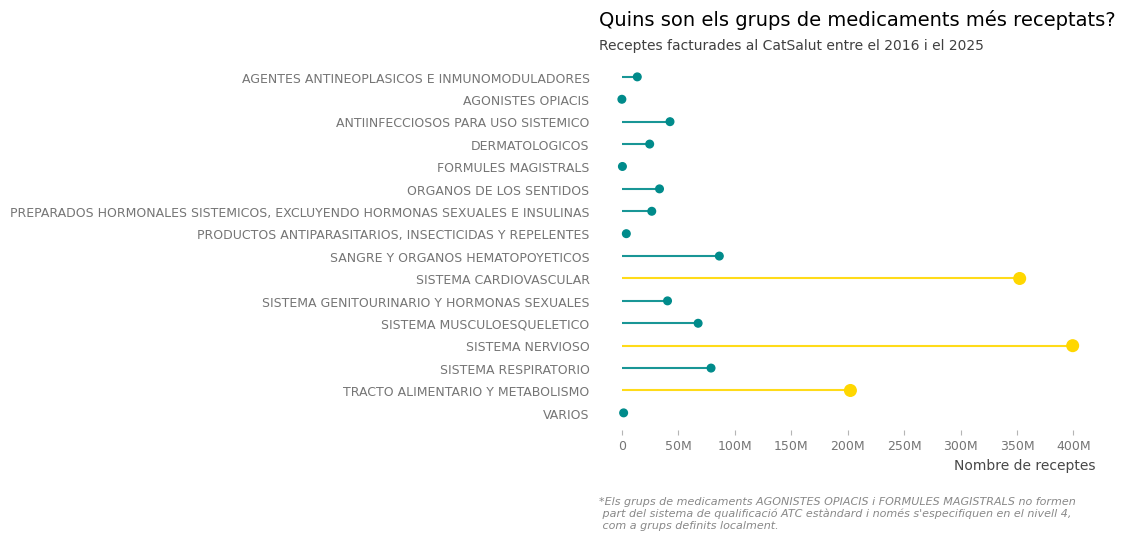

In [52]:
# Creem un lolipop.

# Primer definim variables de format
wdata_grup1_color = np.where(wdata_grup1.index.isin(wdata_grup1_top3), "gold", "darkcyan")
wdata_grup1_mida = np.where(wdata_grup1.index.isin(wdata_grup1_top3), 70, 30)
wdata_grup1_rang = range(1,len(wdata_grup1.index)+1)

# Generem les gràfiques: línies i punts sobre els mateixos eixos
plt.hlines(y=wdata_grup1_rang, xmin=0, xmax=wdata_grup1["nombre de receptes"], color=wdata_grup1_color, alpha=0.9)
plt.scatter(wdata_grup1["nombre de receptes"], wdata_grup1_rang, color=wdata_grup1_color, s=wdata_grup1_mida, alpha=1)
ax = plt.gca()

# Afegim títols, subtítols i notes al peu
plt.yticks(wdata_grup1_rang, wdata_grup1.index)
plt.title("Quins son els grups de medicaments més receptats?", loc="left", size=14, pad=25)
plt.xlabel("Nombre de receptes", loc="right", color="#474747")

ax.text(
    x=0, y=1.02, transform=ax.transAxes, 
    s="Receptes facturades al CatSalut entre el 2016 i el 2025", 
    ha="left", va="bottom", 
    fontsize=10, color="#404040"
)

ax.text(
    x=0, y=-0.18, transform=ax.transAxes,
    s="*Els grups de medicaments AGONISTES OPIACIS i FORMULES MAGISTRALS no formen\n part del sistema de qualificació ATC estàndard i només s'especifiquen en el nivell 4,\n com a grups definits localment.", 
    ha="left", va="top", multialignment="left",
    fontsize=8, color="#888888", style="italic"
)

# Canviem el format
ax.tick_params(axis="y", which="both", left=False, labelcolor="#757575", labelsize=9)
ax.tick_params(axis="x", which="both", color="#b5b5b5", labelcolor="#757575", labelsize=9)

formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1000000:,.0f}M' if x != 0 else '0')
ax.xaxis.set_major_formatter(formatter)

for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)


# Guardem i mostrem el gràfic
plt.savefig(
    "top_grup1.png", 
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [57]:
for grup in wdata_grup1_top3:
    print(grup)
    for i in range(2,5):
        col = "grup ATC nivell "+str(i)
        values = sorted(pd.unique(wdata.loc[wdata["grup ATC nivell 1"]==grup][col]).tolist())
        print("{}: {}".format(col, len(values)))

SISTEMA NERVIOSO
grup ATC nivell 2: 7
grup ATC nivell 3: 20
grup ATC nivell 4: 59
SISTEMA CARDIOVASCULAR
grup ATC nivell 2: 9
grup ATC nivell 3: 31
grup ATC nivell 4: 51
TRACTO ALIMENTARIO Y METABOLISMO
grup ATC nivell 2: 13
grup ATC nivell 3: 27
grup ATC nivell 4: 63


In [58]:
# Preparem un treemap dels tres grups més receptats
# Creem un nou dataframe filtrant pel top 3
wdata_top3_details = wdata[wdata["grup ATC nivell 1"].isin(wdata_grup1_top3)]
wdata_top3_details = wdata_top3_details[["grup ATC nivell 1", "grup ATC nivell 2", "grup ATC nivell 3", "grup ATC nivell 4", "nombre de receptes"]]

# Calculem el rang per a la llegenda comuna
valors_nivell3 = wdata_top3_details.groupby(["grup ATC nivell 1", "grup ATC nivell 3"])["nombre de receptes"].sum()
min_real = valors_nivell3.min()
max_real = valors_nivell3.max()
punts_tall = np.linspace(min_real, max_real, 5)

# Creem l'estructura de mosaic 
fig_treemap = make_subplots(
    rows=1, cols=3,
    specs=[[{"type": "treemap"}, {"type": "treemap"}, {"type": "treemap"}]],
    horizontal_spacing=0.02,
    subplot_titles=[f"{grup}" for grup in wdata_grup1_top3]
)

# Creem tres treemaps, iterant sobre els grups de nivell 1
for i, grup1 in enumerate(wdata_grup1_top3, start=1):    
    wdata_current_grup = wdata_top3_details[wdata_top3_details["grup ATC nivell 1"] == grup1]
    
    temp_fig = px.treemap(
        wdata_current_grup,
        path=["grup ATC nivell 1", "grup ATC nivell 3", "grup ATC nivell 4"],
        values="nombre de receptes",
    )
    
    trace = temp_fig.data[0]
    trace.marker.colors = trace.values
    trace.marker.coloraxis = "coloraxis" 
    trace.maxdepth = 2  
    
    trace.pathbar = dict(
        visible=True,
        side="top",
        edgeshape=">",  
        thickness=20,    
        textfont=dict(size=10, color="#474747")
    )
    
    trace.marker.line = dict(color="white", width=1.5)
    trace.marker.pad = dict(b=0, l=0, r=0, t=0)
    trace.tiling = dict(pad=0)
    trace.hovertemplate = "<b>%{label}</b><br>Receptes: %{value:,}<extra></extra>"
    
    fig_treemap.add_trace(trace, row=1, col=i)

# Modifiquem l'estil del conjunt global
fig_treemap.update_layout(
    title=dict(
        text="Detall dels grups de fàrmacs més receptats",
        x=0.5, y=0.96,
        xanchor='center', yanchor='top',
        font=dict(color="black", size=18)
    ),
    
    height=750,
    margin=dict(t=110, b=140, l=20, r=20),
    
    coloraxis=dict(
        showscale=True,              
        colorscale="Aggrnyl",
        cmin=min_real,
        cmax=max_real,
        colorbar=dict(
            orientation="h",
            len=0.5,
            thickness=12,
            x=0.5, xanchor="center",
            y=-0.12, yanchor="top",
            title=dict(
                text="Nombre de receptes (milions)",
                font=dict(color="#474747", size=11),
                side="top"
            ),
            tickfont=dict(color="#757575", size=10),
            tickmode="array",
            tickvals=punts_tall,
            ticktext=[f"{x/1e6:.1f}" if x != 0 else "0" for x in punts_tall],
        )
    ),
)

fig_treemap.update_annotations(
    font=dict(size=14, color="#404040"),
    yshift=25
)

fig_treemap.update_layout(dragmode=False)
config = {'displayModeBar': False, 'scrollZoom': False}
fig_treemap.show(config=config)

In [24]:
fig_treemap.write_html("detall_top3.html")

In [59]:
# Identifiquem els medicaments (nivell 4) més receptats en els 10 anys
top_per_any = wdata.groupby(["any", "grup ATC nivell 4"])["nombre de receptes"].sum().reset_index()

# Ordenem dins de cada any i seleccionem els 10 més elevats
top_per_any = top_per_any.sort_values(by=["any", "nombre de receptes"], ascending=[True, False])
wdata_top10_list = pd.unique(top_per_any.groupby("any").head(10)["grup ATC nivell 4"]).tolist()

# Filtrem i agrupem
wdata_top10 = wdata[wdata["grup ATC nivell 4"].isin(wdata_top10_list)]
wdata_top10 = wdata_top10.groupby(["any", "grup ATC nivell 1", "grup ATC nivell 4"], as_index=False)["nombre de receptes"].sum()

# Ordenem el dataframe agrupat i eliminem duplicats
wdata_top10 = wdata_top10.sort_values(by=["any", "grup ATC nivell 4", "nombre de receptes"], ascending=[True, True, False])
wdata_top10 = wdata_top10.drop_duplicates(subset=["any", "grup ATC nivell 4"], keep="first")
wdata_top10

,any,grup ATC nivell 1,grup ATC nivell 4,nombre de receptes
2,2016,SISTEMA CARDIOVASCULAR,Agentes beta- bloqueantes selectivos,2563810
7,2016,SISTEMA NERVIOSO,Anilidas,6883179
11,2016,TRACTO ALIMENTARIO Y METABOLISMO,Biguanidas,3087449
8,2016,SISTEMA NERVIOSO,Derivados de la benzodiazepina,8905152
3,2016,SISTEMA CARDIOVASCULAR,Derivados de la dihidropiridina,2723086
...,...,...,...,...
122,2025,SISTEMA CARDIOVASCULAR,Inhibidores de la HMG CoA reductasa,6987937
118,2025,SANGRE Y ORGANOS HEMATOPOYETICOS,"Inhibidores de la agregacion plaquetaria, hepa...",3502485
129,2025,TRACTO ALIMENTARIO Y METABOLISMO,Inhibidores de la bomba de protones,6063286
126,2025,SISTEMA NERVIOSO,Inhibidores selectivos de la recaptacion de se...,3775516


In [60]:
# Visualitzem un resum en forma de taula
wdata_top10_pivot = wdata_top10.pivot_table(
    index='any', 
    columns='grup ATC nivell 4', 
    values='nombre de receptes',
    aggfunc='sum'                  # <-- This aggregates any unexpected duplicates
).fillna(0)

wdata_top10_pivot

grup ATC nivell 4,Agentes beta- bloqueantes selectivos,Anilidas,Biguanidas,Derivados de la benzodiazepina,Derivados de la dihidropiridina,Derivados del acido propionico,"Inhibidores de la ECA, monofarmacos",Inhibidores de la HMG CoA reductasa,"Inhibidores de la agregacion plaquetaria, heparina excl.",Inhibidores de la bomba de protones,Inhibidores selectivos de la recaptacion de serotonina,Otros antidepresivos
any,,,,,,,,,,,,
2016,2563810,6883179,3087449,8905152,2723086,3656880,4437216,8150525,4609107,9290212,3616989,2278272
2017,2742754,6870619,3011300,8864123,2794859,3442348,4506560,7918492,4546764,8622534,3644049,2392347
2018,2861598,6965769,2891259,8919896,2835954,3445984,4523018,7797355,4359525,8024228,3692671,2527305
2019,3035077,7318423,2805738,8950810,2915565,3741636,4603173,7702675,4420803,7720969,3800426,2658425
2020,3187338,7597777,2739531,9217020,2987213,3082798,4615004,7736815,4367250,7650416,3904530,2788482
2021,3306578,7993548,2703840,9422640,3052294,3507657,4642671,7916026,4270632,7790686,4082922,2964253
2022,3458452,9079289,2630389,9346910,3132605,4211612,4689978,8114686,4171938,7870148,4248482,3207636
2023,3619215,9213622,2528616,9174205,3214477,4478746,4751861,8205029,4165652,7750671,4330973,3425622
2024,3797734,9377393,2482537,8935743,3345976,4639738,4869307,8322308,4186164,7584045,4469503,3677463


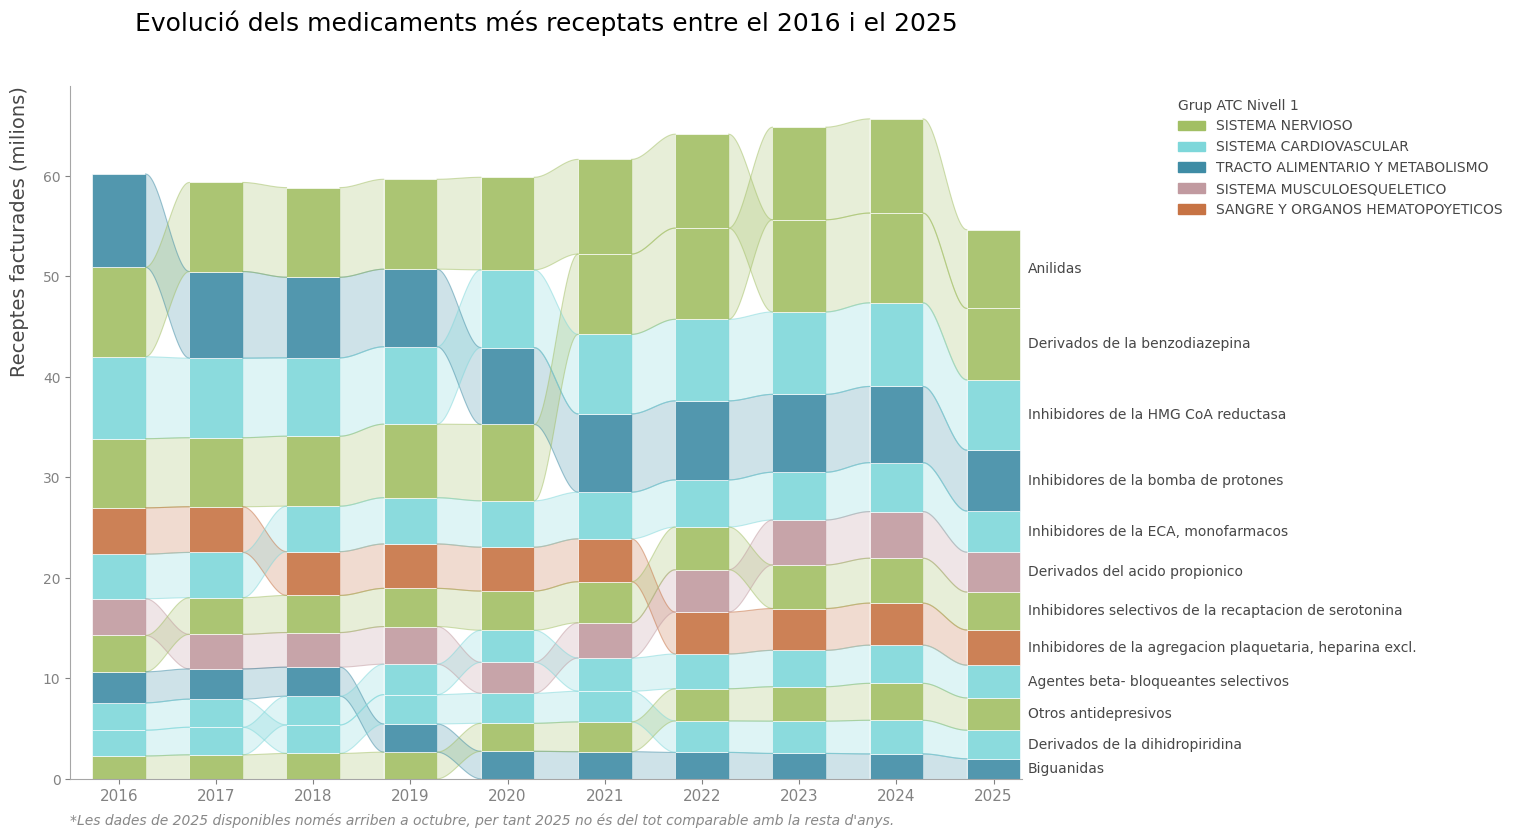

In [61]:
# Ribbon
# Preparem el dataset ordenat
wdata_top10_sorted = wdata_top10.sort_values(by=["any", "nombre de receptes"], ascending=[True, True]).copy()

# Calculem els limits de cada columna
wdata_top10_sorted["bottom"] = wdata_top10_sorted.groupby("any")["nombre de receptes"].cumsum() - wdata_top10_sorted["nombre de receptes"]
wdata_top10_sorted["top"] = wdata_top10_sorted["bottom"] + wdata_top10_sorted["nombre de receptes"]

# Definim una escala de colors per als grups del nivell 1
unique_lvl1 = wdata_top10_sorted["grup ATC nivell 1"].unique()
palette_cmap = load_cmap("Halichoeres_bivittatus", cmap_type="continuous")
palette = palette_cmap(np.linspace(0, 1, len(unique_lvl1)))
color_map = dict(zip(unique_lvl1, palette))

# Configurem la figura
fig, ax = plt.subplots(figsize=(16, 9)) 
bar_width = 0.55
years = sorted(wdata_top10_sorted["any"].unique()) # Fixed variable name
year_to_idx = {year: idx for idx, year in enumerate(years)}

# Creem una funció per definir les corbes entre columnes
def draw_ribbon(ax, x1, x2, y1_low, y1_high, y2_low, y2_high, color):
    x_space = np.linspace(x1, x2, 30)
    t = (x_space - x1) / (x2 - x1)
    smooth_t = 3 * t**2 - 2 * t**3
    
    y_top = y1_high + (y2_high - y1_high) * smooth_t
    y_bottom = y1_low + (y2_low - y1_low) * smooth_t
    
    # Definim l'estètica
    verts = list(zip(x_space, y_top)) + list(zip(x_space[::-1], y_bottom[::-1]))
    poly = patches.Polygon(verts, facecolor=color, alpha=0.25, edgecolor='none')
    ax.add_patch(poly)
    
    ax.plot(x_space, y_top, color=color, linewidth=0.8, alpha=0.5)
    ax.plot(x_space, y_bottom, color=color, linewidth=0.8, alpha=0.5)

# Preparem la gràfica de barres
for year in years:
    year_idx = year_to_idx[year]
    df_year = wdata_top10_sorted[wdata_top10_sorted['any'] == year]
    
    for _, row in df_year.iterrows():
        color = color_map[row['grup ATC nivell 1']]
        ax.bar(
            year_idx, row['nombre de receptes'], 
            bottom=row['bottom'], width=bar_width, 
            color=color, alpha=0.9, edgecolor='white', linewidth=0.5
        )

# Afegim els ribbon
for i in range(len(years) - 1):
    y1, y2 = years[i], years[i+1]
    df_y1 = wdata_top10_sorted[wdata_top10_sorted["any"] == y1].set_index("grup ATC nivell 4")
    df_y2 = wdata_top10_sorted[wdata_top10_sorted["any"] == y2].set_index("grup ATC nivell 4")
    
    x1 = i + (bar_width / 2)
    x2 = i + 1 - (bar_width / 2)
    
    for cat in wdata_top10_list:
        if cat in df_y1.index and cat in df_y2.index:
            row1 = df_y1.loc[cat]
            row2 = df_y2.loc[cat]
            

            if isinstance(row1, pd.DataFrame):
                lvl1_val = row1["grup ATC nivell 1"].iloc[0]
                r1_bottom = row1['bottom'].iloc[0]
                r1_top = row1['top'].iloc[0]
                r2_bottom = row2['bottom'].iloc[0] if isinstance(row2, pd.DataFrame) else row2['bottom']
                r2_top = row2['top'].iloc[0] if isinstance(row2, pd.DataFrame) else row2['top']
            else:
                lvl1_val = row1["grup ATC nivell 1"]
                r1_bottom = row1['bottom']
                r1_top = row1['top']
                r2_bottom = row2['bottom'].iloc[0] if isinstance(row2, pd.DataFrame) else row2['bottom']
                r2_top = row2['top'].iloc[0] if isinstance(row2, pd.DataFrame) else row2['top']
            
            color = color_map[lvl1_val]
            
            draw_ribbon(ax, x1, x2, r1_bottom, r1_top, r2_bottom, r2_top, color)

# Afegim els noms dels medicaments al costat de la columna 2025
last_year = years[-1]
df_last_year = wdata_top10_sorted[wdata_top10_sorted['any'] == last_year]
last_year_idx = year_to_idx[last_year]

for _, row in df_last_year.iterrows():
    y_position = (row['bottom'] + row['top']) / 2
    x_position = last_year_idx + (bar_width / 2) + 0.08
    
    ax.text(
        x_position, y_position, 
        row['grup ATC nivell 4'], 
        va='center', ha='left', 
        fontsize=10, color='#474747',
        weight='medium',
        clip_on=False # <-- IMPROVEMENT 2: Allows text to sit safely outside axis limits
    )

# Modifiquem el format
ax.set_title("Evolució dels medicaments més receptats entre el 2016 i el 2025", fontsize=18, pad=40)
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, fontsize=11, color="#474747")
ax.set_xlabel("")
ax.set_ylabel("Receptes facturades (milions)", fontsize=14, labelpad=10, color="#474747", loc="top")
sns.despine(ax=ax) 
ax.spines['left'].set_color('#a6a6a6')
ax.spines['bottom'].set_color('#a6a6a6')
ax.tick_params(axis='both', colors='#828282')
ax.set_xlim(-0.5, len(years) - 1 + (bar_width / 2) + 0.02)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.1f}'.rstrip('0').rstrip('.')))
legend_handles = [patches.Patch(color=color_map[lvl1], label=lvl1) for lvl1 in unique_lvl1]

legend = ax.legend(
    handles=legend_handles, 
    title="Grup ATC Nivell 1", 
    loc='upper left', 
    bbox_to_anchor=(1.15, 1.0), # Positions it tightly to the right of the Level 4 text labels
    frameon=False
)

legend.get_title().set_color('#474747')
plt.setp(legend.get_texts(), color='#474747')
legend._legend_box.align = "left"

ax.text(
    x=0, y=-0.05, transform=ax.transAxes,
    s="*Les dades de 2025 disponibles només arriben a octubre, per tant 2025 no és del tot comparable amb la resta d'anys.", 
    ha="left", va="top", multialignment="left",
    fontsize=10, color="#888888", style="italic"
)

plt.subplots_adjust(right=0.72)

# Guardem i mostrem
plt.savefig(
    "ribbon_evolucio.png", 
    dpi=300,                 # High resolution for web screens
    bbox_inches="tight",     # Prevents titles/footnotes from being cut off
    transparent=True         # Removes the white background so it blends into Canva
)

plt.show()

In [62]:
# Piramides de població
# Preparem les dades de receptes per grups d'edats i visualitzem el resum per comprovar-ne el resultat després
sorted(pd.unique(wdata["grup d'edat"]).tolist())

wdata_piramide = wdata.pivot_table(
    index="grup d'edat", 
    columns="sexe", 
    values="nombre de receptes",
    aggfunc="sum"
).fillna(0)

wdata_piramide

sexe,Dona,Home
grup d'edat,,
0-1,2428082,2970383
10-11,1906413,2483291
12-13,1902758,2504976
14-15,2309534,2474162
16-17,2940763,2467115
18-19,3239086,2240214
2-3,2270053,2740603
20-24,8950218,5609947
25-29,10658968,6416601


In [63]:
# Ordenem els grups d'edat
grups_edats = [
    "0-1", "2-3", "4-5", "6-7", "8-9", "10-11", "12-13", "14-15", 
    "16-17", "18-19", "20-24", "25-29", "30-34", "35-39", "40-44", 
    "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75-79", 
    "80-84", "Més de 84"
]
wdata_piramide.reindex(grups_edats)

# Definim els eixos
y_edats=wdata_piramide.index
x_homes = wdata_piramide["Home"] * -1  
x_dones = wdata_piramide["Dona"]

# Generem la figura
fig_piramide = go.Figure()

# Afegim les barres per als homes
fig_piramide.add_trace(go.Bar(
    y=y_edats,
    x=x_homes,
    name="Homes",
    orientation="h",
    marker_color="#00ced1",
    hoverinfo="text",
    hovertext=[
        f"{grup} anys<br>{abs(val/1000000):,.1f} milions de receptes" 
        for grup, val in zip(wdata_piramide.index, wdata_piramide["Home"])
    ]
))

# Afegim les barres per a les dones
fig_piramide.add_trace(go.Bar(
    y=y_edats,
    x=x_dones,
    name="Dones",
    orientation="h",
    marker_color="gold",
    hoverinfo="text",
    hovertext=[
        f"{grup} anys<br>{abs(val/1000000):,.1f} milions de receptes" 
        for grup, val in zip(wdata_piramide.index, wdata_piramide["Dona"])
    ]
))

# Modifiquem el format
fig_piramide.update_layout(
    height=700,
    title="Receptes venudes per edat i sexe",
    title_x=0.45,
    barmode="relative",
    yaxis=dict(title="Grup d'edat",
              type="category",
              categoryorder='array',
              categoryarray=grups_edats),
    xaxis=dict(
        tickvals = [-100000000, -50000000, 0, 50000000, 100000000],
        ticktext=["100", "50", "0", "50", "100"]
    ),
    bargap=0.2,
    template='plotly_white',

    annotations=[
        dict(
            text="Nombre de receptes (milions)",
            xref="paper",
            yref="paper",      
            x=0.4,
            y=-0.1,
            showarrow=False,
            font=dict(size=14, color="#2c3e50") # Estilo del texto
        )
    ]
)
fig_piramide.update_layout(dragmode=False)
config = {'displayModeBar': False, 'scrollZoom': False}

# Mostramos el gráfico
fig_piramide.show(config=config)

In [30]:
# Guardem
fig_piramide.write_html("piramide_global.html")

In [64]:
# Generem un nou detall per grup atc 1 i filtrem només els 3 grups més receptats
wdata_top3_details_people = wdata[wdata["grup ATC nivell 1"].isin(wdata_grup1_top3)]
wdata_top3_details_people = wdata_top3_details_people[["any", "grup d'edat", "sexe", "grup ATC nivell 1", "grup ATC nivell 2", "grup ATC nivell 3", "grup ATC nivell 4", "nombre de receptes"]]

wdata_piramide_filtered = wdata_top3_details_people.pivot_table(
    index="grup d'edat", 
    columns=["sexe", "grup ATC nivell 1"], 
    values="nombre de receptes",
    aggfunc="sum"
).fillna(0)

wdata_piramide_filtered

sexe                                Dona                   \
grup ATC nivell 1 SISTEMA CARDIOVASCULAR SISTEMA NERVIOSO   
grup d'edat                                                 
0-1                                18678           534313   
10-11                              24629           415386   
12-13                              28056           474717   
14-15                              31744           679523   
16-17                              34980           864116   
18-19                              33724           868314   
2-3                                11542           361523   
20-24                              98934          2419445   
25-29                             166313          3131687   
30-34                             321759          4550978   
35-39                             702218          7232931   
4-5                                12992           316844   
40-44                            1616199         11516403   
45-49                            3477724         15636186   
50-54                            6741648         18789713   
55-59                           10965284         21268229   
6-7                                17042           323680   
60-64                           15519250         22588718   
65-69                           20604384         23877482   
70-74                           25707092         27098645   
75-79                           27277640         28468935   
8-9                                21258           370113   
80-84                           25913281         28174265   
Més de 84                       35520778         42934379   

sexe                                                                 Home  \
grup ATC nivell 1 TRACTO ALIMENTARIO Y METABOLISMO SISTEMA CARDIOVASCULAR   
grup d'edat                                                                 
0-1                                         425318                  16482   
10-11                                        96965                  56547   
12-13                                       120405                  64812   
14-15                                       150512                  66173   
16-17                                       182412                  62716   
18-19                                       205804                  50957   
2-3                                          76590                  15369   
20-24                                       598781                 126039   
25-29                                       760361                 186153   
30-34                                      1060127                 414459   
35-39                                      1599104                1059743   
4-5                                          67848                  18939   
40-44                                      2544333                2728224   
45-49                                      3842802                5982352   
50-54                                      5642759               10851836   
55-59                                      8017175               16610898   
6-7                                          69189                  27877   
60-64                                     10497746               21922002   
65-69                                     13267532               26251759   
70-74                                     15702165               28424772   
75-79                                     15810895               25368204   
8-9                                          81239                  42361   
80-84                                     14190755               19274260   
Més de 84                                 18053783               17877740   

sexe                                                                 
grup ATC nivell 1 SISTEMA NERVIOSO TRACTO ALIMENTARIO Y METABOLISMO  
grup d'edat                                                          
0-1                         608663                           4

In [65]:
# Reordenem i generem l'index
wdata_piramide_filtered.reindex(grups_edats)
y_edats=wdata_piramide_filtered.index

# Creem la figura
fig_piramide_filtered = go.Figure()

# Definim les paletes de colors
colors_homes = {
    wdata_grup1_top3[0]: "#008b8b", # DarkCyan
    wdata_grup1_top3[1]: "#00ced1", # dark turquoise
    wdata_grup1_top3[2]: "#98f5ff"  # CadetBlue1
}

colors_dones = {
    wdata_grup1_top3[0]: "#cd9b1d", # goldenrod3
    wdata_grup1_top3[1]: "#ffd700", # Gold
    wdata_grup1_top3[2]: "#fff68f"  # khaki1
}

# Iterem sobre cada grup per anar dibuixant les columnes apilades
for atc in wdata_grup1_top3:
    
    x_homes = wdata_piramide_filtered.get(("Home", atc), pd.Series(0, index=y_edats)) * -1  
    x_dones = wdata_piramide_filtered.get(("Dona", atc), pd.Series(0, index=y_edats))

    # Homes
    fig_piramide_filtered.add_trace(go.Bar(
        y=y_edats,
        x=x_homes,
        name=f"{atc}",
        showlegend=False,
        legendgroup=atc,
        orientation="h",
        marker_color=colors_homes[atc],
        hoverinfo="text",
        hovertext=[
            f"<b>{grup} anys</b><br>{atc}<br>Homes: {abs(val/1000000):,.1f} milions de receptes" 
            for grup, val in zip(y_edats, x_homes)
        ]
    ))

    # Dones
    fig_piramide_filtered.add_trace(go.Bar(
        y=y_edats,
        x=x_dones,
        name=f"{atc}",
        showlegend=False,
        legendgroup=atc,
        orientation="h",
        marker_color=colors_dones[atc],
        hoverinfo="text",
        hovertext=[
            f"<b>{grup} anys</b><br>{atc}<br>Dones: {abs(val/1000000):,.1f} milions de receptes" 
            for grup, val in zip(y_edats, x_dones)
        ]
    ))

    texto_leyenda = f"<span style='color:{colors_homes[atc]};'>■</span> <span style='color:{colors_dones[atc]};'>■</span> {atc}"
    
    fig_piramide_filtered.add_trace(go.Scatter(
        x=[None], 
        y=[None], 
        mode='markers',
        marker=dict(color='rgba(0,0,0,0)', size=1), 
        name=texto_leyenda,
        showlegend=True,
        legendgroup=atc,
        hoverinfo='none' 
    ))

# Modifiquem formats
fig_piramide_filtered.update_layout(
    height=700,
    title="Receptes venudes per edat, sexe i grup ATC",
    title_x=0.2,
    barmode="relative", # Esto es clave: apila negativos a un lado y positivos al otro
    yaxis=dict(title="Grup d'edat",
              type="category",
              categoryorder='array',
              categoryarray=grups_edats),
    xaxis=dict(
        tickvals = [-100000000, -50000000, 0, 50000000, 100000000],
        ticktext=["100", "50", "0", "50", "100"]
    ),
    bargap=0.2,
    template='plotly_white',
    legend=dict(
        # Añadimos un pequeño título a la leyenda para aclarar qué es cada cuadrado
        title=dict(
            text="<span style='font-size:12px; color:gray'>Homes | Dones</span>",
            font=dict(size=12)
        ),
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.05
    ),
    annotations=[
         dict(
            text="Distribució dels tres grups de medicaments més venuts entre la població, per edat i sexe",
            xref="paper",
            yref="paper",      
            x=0.4,
            y=1.07,
            showarrow=False,
            font=dict(size=14, color="#2c3e50")
        ),
        dict(
            text="Nombre de receptes (milions)",
            xref="paper",
            yref="paper",      
            x=0.4,
            y=-0.15,
            showarrow=False,
            font=dict(size=14, color="#2c3e50")
        )
    ]
)

fig_piramide_filtered.update_layout(dragmode=False) 
config = {'displayModeBar': False, 'scrollZoom': False}

fig_piramide_filtered.show(config=config)

In [34]:
fig_piramide_filtered.write_html("piramide_top3.html")

In [35]:
# Circles
# Agrupem les edats en quatre categories
map_edats = {
    "0-1": "infants (0-15 anys)", "2-3": "infants (0-15 anys)", "4-5": "infants (0-15 anys)", "6-7": "infants (0-15 anys)", "8-9": "infants (0-15 anys)",
    "10-11": "infants (0-15 anys)", "12-13": "infants (0-15 anys)", "14-15": "infants (0-15 anys)", "16-17": "joves (16-34 anys)", "18-19": "joves (16-34 anys)", 
    "20-24": "joves (16-34 anys)", "25-29": "joves (16-34 anys)", "30-34": "joves (16-34 anys)", "35-39": "adults (35-69 anys)", "40-44": "adults (35-69 anys)",
    "45-49": "adults (35-69 anys)", "50-54": "adults (35-69 anys)", "55-59": "adults (35-69 anys)", "60-64": "adults (35-69 anys)", "65-69": "adults (35-69 anys)",
    "70-74": "gent gran (70 anys o més)", "75-79": "gent gran (70 anys o més)", "80-84": "gent gran (70 anys o més)", "Més de 84": "gent gran (70 anys o més)"
}

wdata["categoria_edat"] = wdata["grup d'edat"].map(map_edats)

In [36]:
# Creem un nou dataframe per veure el grup atc 1 del sistema nervios per edats
wdata_sistnerv = wdata[wdata["grup ATC nivell 1"] == wdata_grup1_top3[0]]
wdata_sistnerv = wdata_sistnerv[["any", "categoria_edat", "sexe", "grup ATC nivell 1", "grup ATC nivell 3", "grup ATC nivell 4", "nombre de receptes"]]

wdata_circlify = wdata_sistnerv.groupby(
    ["grup ATC nivell 4", "categoria_edat"], 
    as_index=False
)["nombre de receptes"].sum()

# Limitem el nombre de registres per fer el gràfic més comprensible
wdata_circlify = wdata_circlify[wdata_circlify["nombre de receptes"] > 150000]
wdata_circlify = wdata_circlify.sort_values("nombre de receptes", ascending=False)

wdata_circlify

,grup ATC nivell 4,categoria_edat,nombre de receptes
52,Derivados de la benzodiazepina,adults (35-69 anys),50700025
33,Anilidas,gent gran (70 anys o més),45582242
53,Derivados de la benzodiazepina,gent gran (70 anys o més),34109990
32,Anilidas,adults (35-69 anys),25968290
158,Inhibidores selectivos de la recaptacion de se...,adults (35-69 anys),21270828
...,...,...,...
76,Derivados de la oripavina,adults (35-69 anys),197510
142,Gabapentinoides,joves (16-34 anys),185272
91,Derivados del indol,adults (35-69 anys),167344
223,Preparados contra el vertigo,joves (16-34 anys),166837


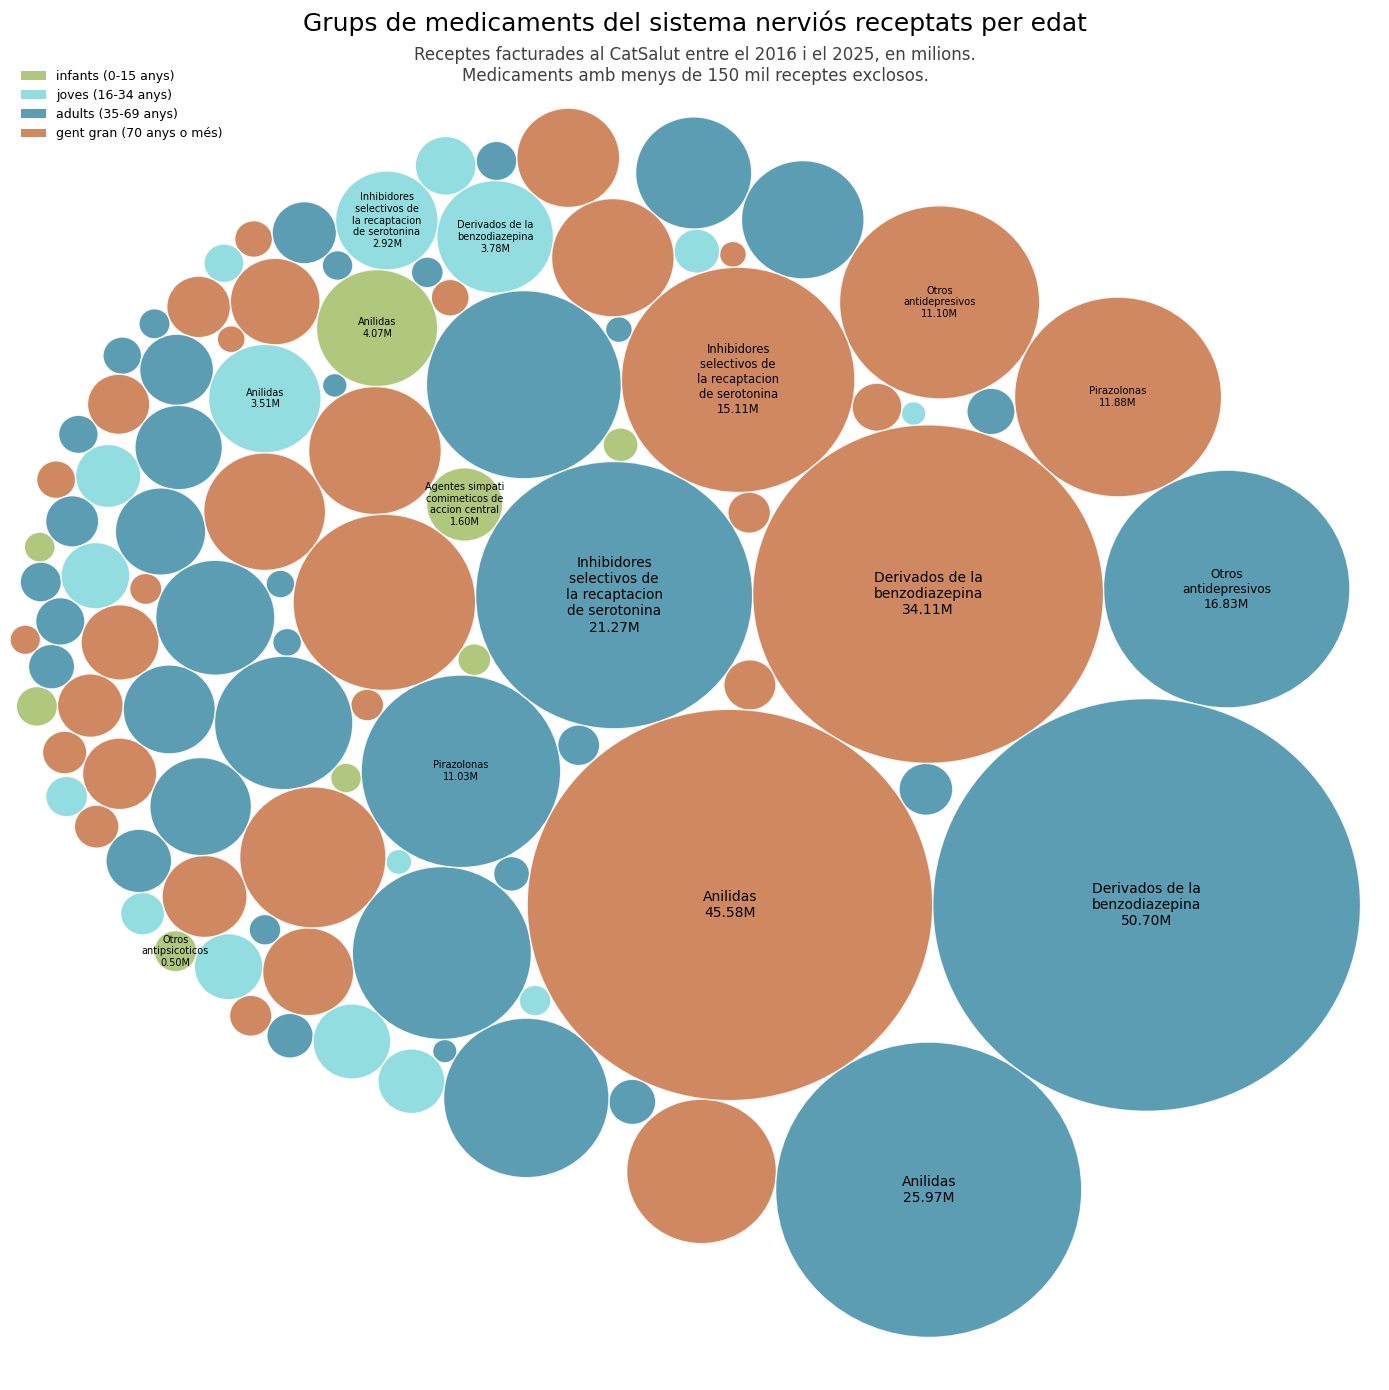

In [66]:
# Limitem les bombolles que tindran text
limits_edat = {
    "infants (0-15 anys)": 3,
    "joves (16-34 anys)": 3,
    "adults (35-69 anys)": 5,
    "gent gran (70 anys o més)": 5
}

ids_amb_text = set()
for edat, limit in limits_edat.items():
    top_cat = wdata_circlify[wdata_circlify["categoria_edat"] == edat].head(limit)
    ids_amb_text.update(top_cat["grup ATC nivell 4"] + " - " + top_cat["categoria_edat"])

# Preparem les dades per circlify
data_circles = []
diccionario_datos = {} 

for _, row in wdata_circlify.iterrows():
    id_unico = f"{row["grup ATC nivell 4"]} - {row["categoria_edat"]}"
    
    data_circles.append({
        "id": id_unico, 
        "datum": row["nombre de receptes"]/1000000
    })
    
    diccionario_datos[id_unico] = {
        "edat": row["categoria_edat"],
        "atc4": row["grup ATC nivell 4"]
    }

# Calculem les posicions dels cercles
circles = circlify.circlify(
    data_circles,
    show_enclosure=False,
    target_enclosure=circlify.Circle(x=0, y=0, r=1)
)


fig, ax = plt.subplots(figsize=(14, 14))
ax.axis("off")

colors_edat = {
    "infants (0-15 anys)": "#A2BF64FF",   
    "joves (16-34 anys)": "#7ED7DAFF",     
    "adults (35-69 anys)": "#3E8CA5FF",    
    "gent gran (70 anys o més)": "#C77344FF"
}

for circle in circles:
    id_circulo = circle.ex["id"]
    receptes = circle.ex["datum"]
    
    atc4 = diccionario_datos[id_circulo]["atc4"]
    edat = diccionario_datos[id_circulo]["edat"]
    
    c = plt.Circle(
        (circle.x, circle.y), circle.r,
        alpha=0.85, 
        facecolor=colors_edat.get(edat, "#cccccc"),
        edgecolor="#ffffff", linewidth=1 
    )
    ax.add_patch(c)
    
    if id_circulo in ids_amb_text: 
        atc4_format = textwrap.fill(atc4, width=15)
        mida_font = max(min(10, circle.r * 50),7)
        ax.text(circle.x, circle.y, f"{atc4_format}\n{receptes:,.2f}M", 
                ha='center', va='center', fontsize=mida_font, color="black")

ax.text(
    x=0.5, y=0.98, transform=ax.transAxes, 
    s="Receptes facturades al CatSalut entre el 2016 i el 2025, en milions.\nMedicaments amb menys de 150 mil receptes exclosos.", 
    ha="center", va="bottom", 
    fontsize=12, color="#404040"
)

lim = max(max(abs(circle.x) + circle.r, abs(circle.y) + circle.r) for circle in circles)
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

legend_elements = [patches.Patch(facecolor=color, label=edat, alpha=0.85) 
                   for edat, color in colors_edat.items()]
ax.legend(handles=legend_elements, 
          loc="upper left", fontsize=9, frameon=False)

plt.title("Grups de medicaments del sistema nerviós receptats per edat", fontsize=18, pad=20)
plt.tight_layout()

plt.savefig(
    "bubbles_sistnervios.png", 
    dpi=300,                 # High resolution for web screens
    bbox_inches="tight",     # Prevents titles/footnotes from being cut off
    transparent=True         # Removes the white background so it blends into Canva
)

plt.show()

In [67]:
# Calculem l'aportació de l'usuari
wdata["aportació usuari"] = wdata["import íntegre"]-wdata["import aportació CatSalut"]
wdata.head(5)

,any,mes,codi de la regió sanitària,regió sanitària,grup d'edat,sexe,codi del grup ATC nivell 1,grup ATC nivell 1,codi del grup ATC nivell 2,grup ATC nivell 2,...,grup ATC nivell 3,codi del grup ATC nivell 4,grup ATC nivell 4,nombre de receptes,nombre d'envasos,import íntegre,import aportació CatSalut,categoria_edat,aportació usuari,import aportació usuari per recepta
0,2025,10,61,LLEIDA,0-1,Dona,A,TRACTO ALIMENTARIO Y METABOLISMO,A01,PREPARADOS ESTOMATOLOGICOS,...,PREPARADOS ESTOMATOLOGICOS,A01AB,Antiinfecciosos y antisepticos para el tratami...,2,2,5.66,3.40,infants (0-15 anys),2.26,1.13
1,2025,10,61,LLEIDA,0-1,Dona,A,TRACTO ALIMENTARIO Y METABOLISMO,A02,AGENTES PARA EL TRATAMIENTO DE ALTERACIONES CA...,...,AGENTES CONTRA LA ULCERA PEPTICA Y EL REFLUJO ...,A02BC,Inhibidores de la bomba de protones,1,1,17.75,10.65,infants (0-15 anys),7.10,7.10
2,2025,10,61,LLEIDA,0-1,Dona,A,TRACTO ALIMENTARIO Y METABOLISMO,A07,"ANTIDIARREICOS, AGENTES ANTIINFLAMATORIOS/ANTI...",...,ANTIINFECCIOSOS INTESTINALES,A07AA,Antibioticos,21,21,98.28,63.21,infants (0-15 anys),35.07,1.67
3,2025,10,61,LLEIDA,0-1,Dona,A,TRACTO ALIMENTARIO Y METABOLISMO,A07,"ANTIDIARREICOS, AGENTES ANTIINFLAMATORIOS/ANTI...",...,ELECTROLITOS CON CARBOHIDRATOS,A07CA,Formulaciones de sales de rehidratacion oral,60,60,207.72,126.84,infants (0-15 anys),80.88,1.35
4,2025,10,61,LLEIDA,0-1,Dona,A,TRACTO ALIMENTARIO Y METABOLISMO,A11,VITAMINAS,...,"VITAMINAS A Y D, INCLUYENDO COMBINACIONES DE L...",A11CC,Vitamina D y analogos,325,325,"1,597.48","1,013.94",infants (0-15 anys),583.54,1.80


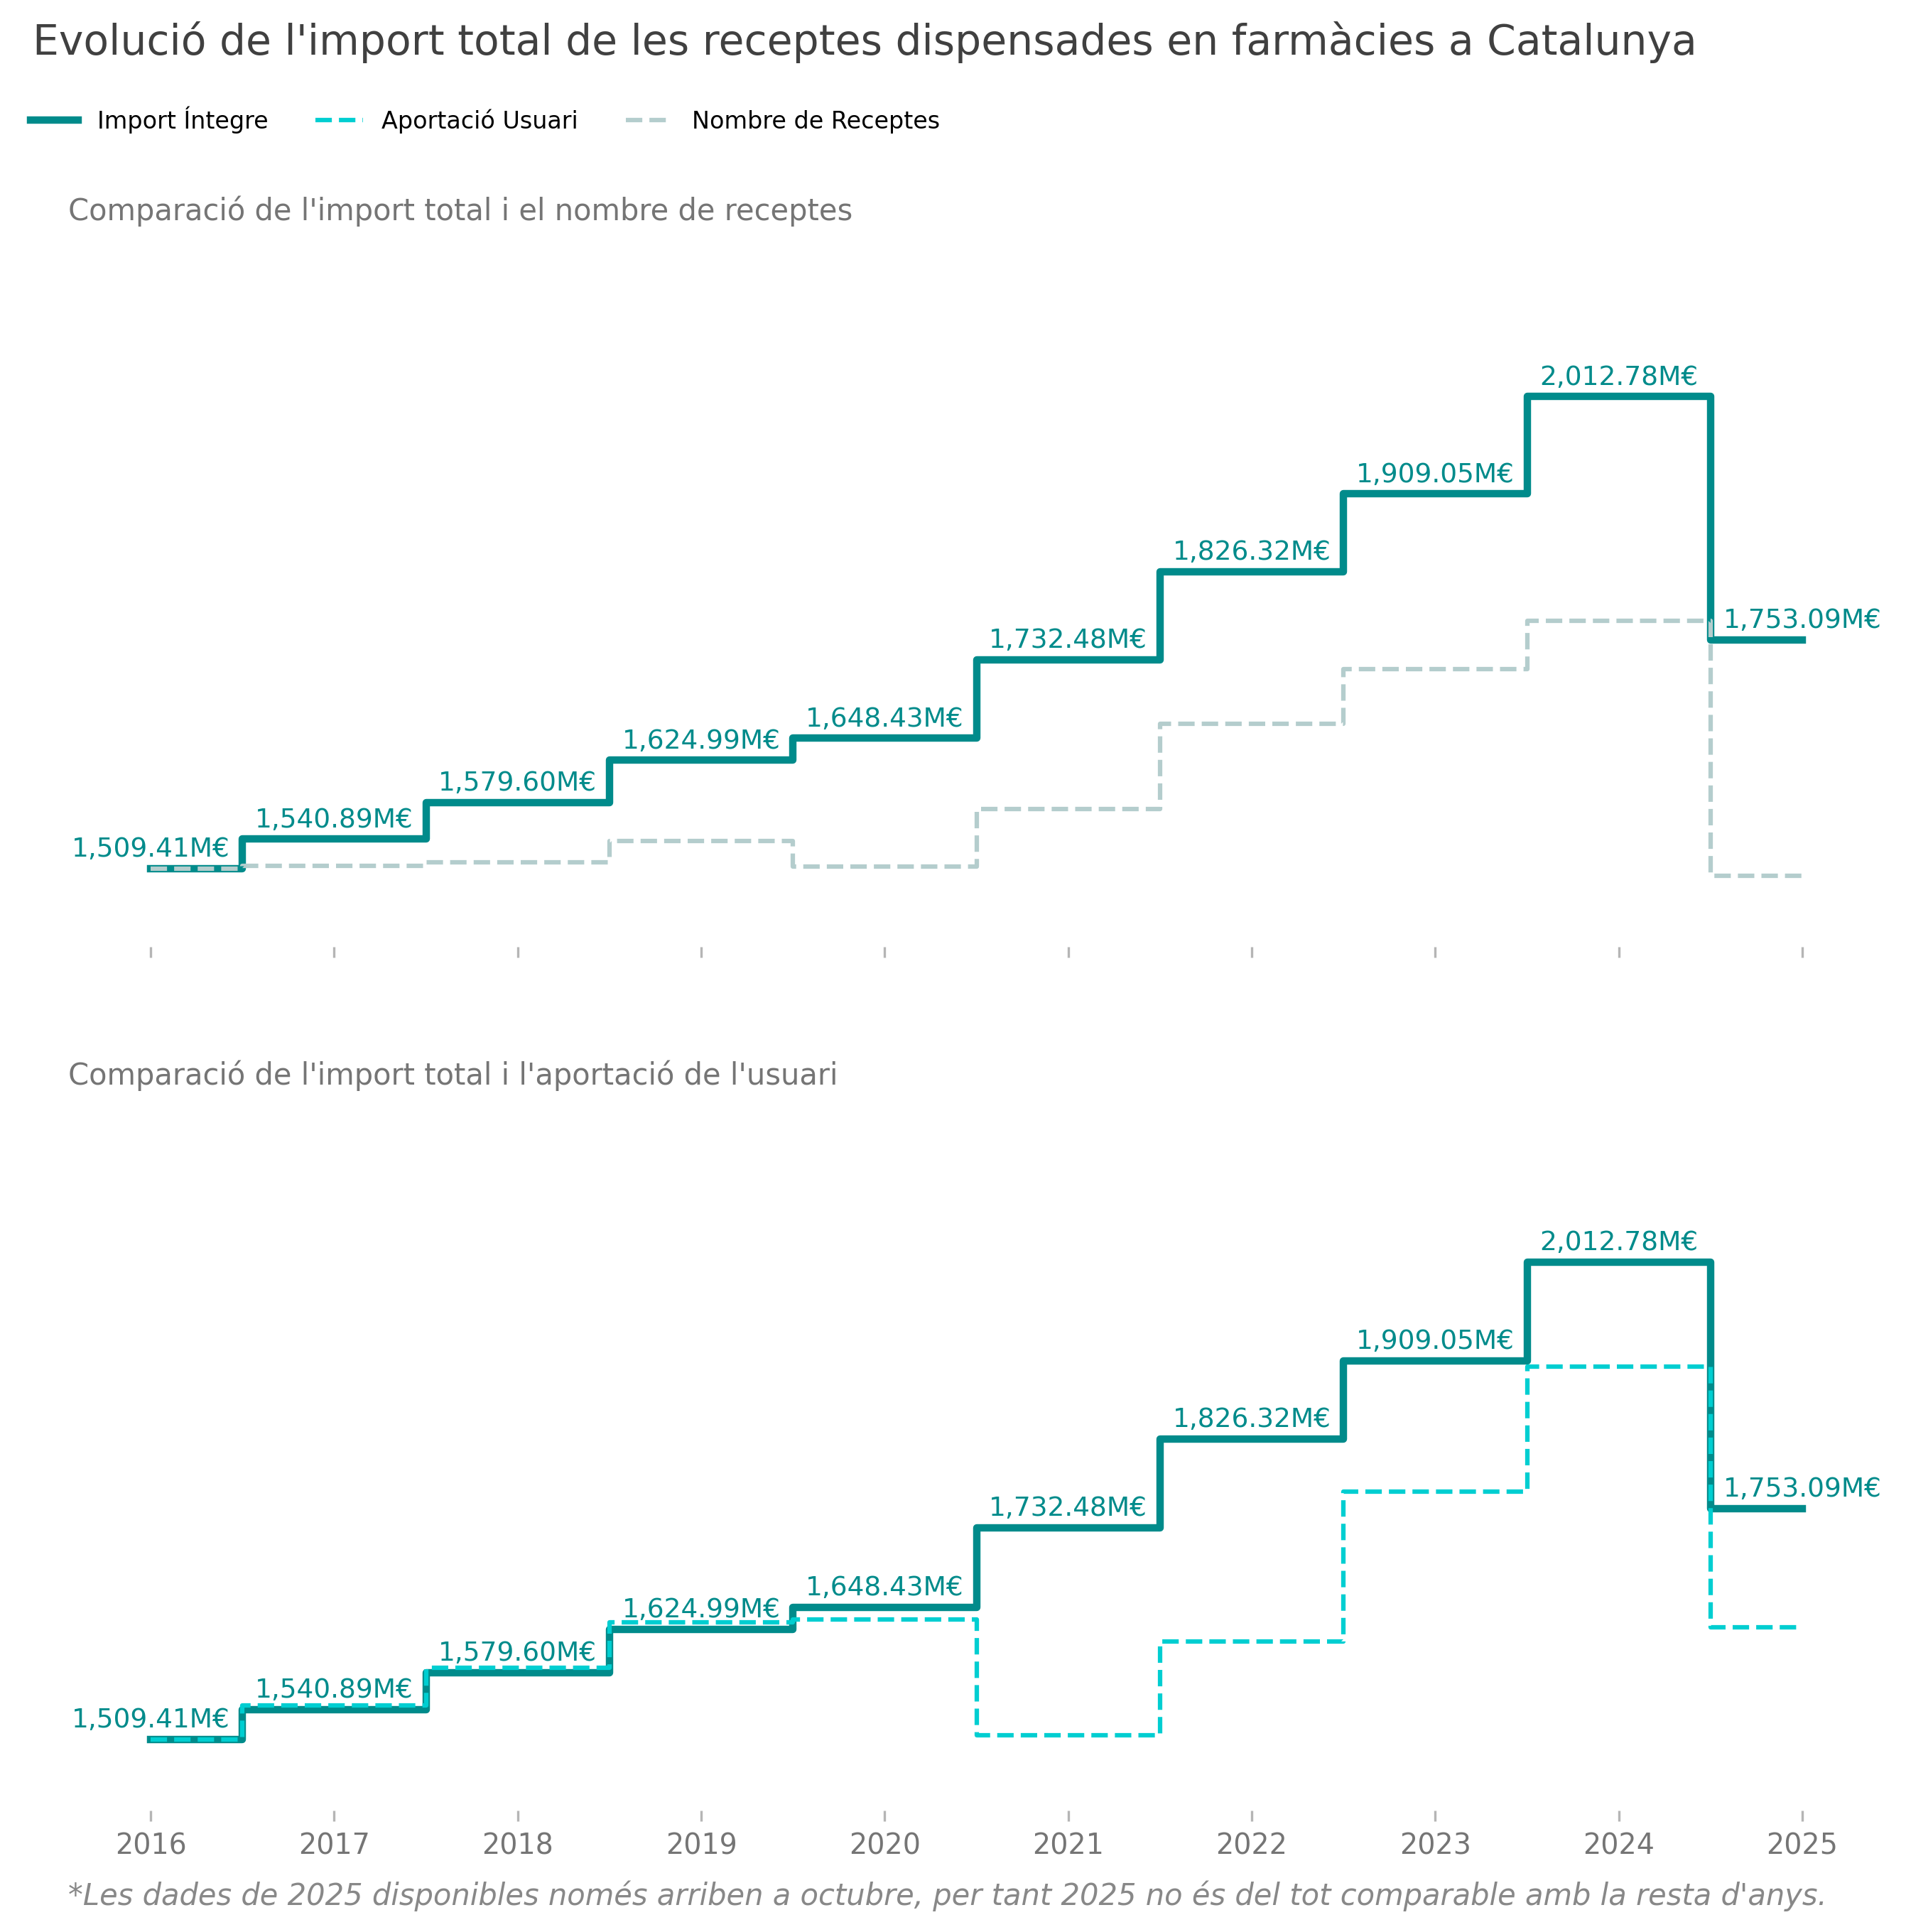

In [69]:
# Steps
# Agrupem per any
data_grouped = wdata.groupby('any')[['import íntegre', 'nombre de receptes', 'aportació usuari']].sum().reset_index()
años = data_grouped['any']
valores_import = data_grouped['import íntegre']
valores_usuari = data_grouped['aportació usuari']
valores_recetas = data_grouped['nombre de receptes']

# Definim paletes de colors
color_import = "darkcyan"
color_usuari = "#00ced1"
color_recetas = "#b4cdcd"

# Creem la figura
fig, (ax_top1, ax_bottom1) = plt.subplots(2, 1, figsize=(11, 10), dpi=300, sharex=True)

# Creem dos eixos y
ax_top2 = ax_top1.twinx()
ax_bottom2 = ax_bottom1.twinx()


# Unifiquem punts de sortida
rel_import_top = valores_import / valores_import.iloc[0]
rel_recetas_top = valores_recetas / valores_recetas.iloc[0]

global_max_top = max(rel_import_top.max(), rel_recetas_top.max())
global_min_top = min(rel_import_top.min(), rel_recetas_top.min())

rel_ymax_top = global_max_top + 0.10
rel_ymin_top = global_min_top - 0.05

ax_top1.set_ylim(rel_ymin_top * valores_import.iloc[0], rel_ymax_top * valores_import.iloc[0])
ax_top2.set_ylim(rel_ymin_top * valores_recetas.iloc[0], rel_ymax_top * valores_recetas.iloc[0])

rel_import_bot = valores_import / valores_import.iloc[0]
rel_usuari_bot = valores_usuari / valores_usuari.iloc[0]

global_max_bot = max(rel_import_bot.max(), rel_usuari_bot.max())
global_min_bot = min(rel_import_bot.min(), rel_usuari_bot.min())

rel_ymax_bot = global_max_bot + 0.10
rel_ymin_bot = global_min_bot - 0.05

ax_bottom1.set_ylim(rel_ymin_bot * valores_import.iloc[0], rel_ymax_bot * valores_import.iloc[0])
ax_bottom2.set_ylim(rel_ymin_bot * valores_usuari.iloc[0], rel_ymax_bot * valores_usuari.iloc[0])


# Creem la gràfica superior
line_import = ax_top1.step(años, valores_import, where='mid', color=color_import, linewidth=2.5, zorder=3)
line_recetas = ax_top2.step(años, valores_recetas, where='mid', color=color_recetas, linewidth=1.5, linestyle='--', zorder=1)

# Creem la gràfica inferior
ax_bottom1.step(años, valores_import, where='mid', color=color_import, linewidth=2.5, zorder=3)
line_usuari = ax_bottom2.step(años, valores_usuari, where='mid', color=color_usuari, linewidth=1.5, linestyle='--', zorder=1)


# Afegim etiquetes
offset_top = (ax_top1.get_ylim()[1] - ax_top1.get_ylim()[0]) * 0.01
for x, y in zip(años, valores_import):
    label = f"{y/1000000:,.2f}M€"
    ax_top1.text(
        x, y + offset_top, label, 
        ha='center', va='bottom', 
        color=color_import, fontsize=9
    )

offset_bot = (ax_bottom1.get_ylim()[1] - ax_bottom1.get_ylim()[0]) * 0.01
for x, y in zip(años, valores_import):
    label = f"{y/1000000:,.2f}M€"
    ax_bottom1.text(
        x, y + offset_bot, label, 
        ha='center', va='bottom', 
        color=color_import, fontsize=9
    )


# Definim formats
fig.suptitle("Evolució de l'import total de les receptes dispensades en farmàcies a Catalunya", x=0.11, y=0.96, ha='left', size=14, color="#404040")

ax_top1.set_title("Comparació de l'import total i el nombre de receptes", loc="left", size=10, color="#757575", pad=12)
ax_bottom1.set_title("Comparació de l'import total i l'aportació de l'usuari", loc="left", size=10, color="#757575", pad=12)

# Crear la leyenda unificada con los tres estilos
handles = [line_import[0], line_usuari[0], line_recetas[0]]
labels = ["Import Íntegre", "Aportació Usuari", "Nombre de Receptes"]
fig.legend(handles=handles, labels=labels, loc="upper left", ncol=3, bbox_to_anchor=(0.1, 0.93), frameon=False, fontsize=8)


for ax in [ax_top1, ax_top2, ax_bottom1, ax_bottom2]:
    ax.get_yaxis().set_visible(False)
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

ax_top1.tick_params(
    axis="x", 
    which="both", 
    color="#b5b5b5",         # Color de la rayita del tick
    labelcolor="#555555",    # Color del texto del año (cámbialo por el que quieras)
    labelsize=9.5, 
    bottom=True
)

ax_bottom1.set_xticks(años)
ax_bottom1.tick_params(axis="x", which="both", color="#b5b5b5", labelcolor="#757575", labelsize=9.5, bottom=True)

ax.text(
    x=0, y=-0.1, transform=ax.transAxes,
    s="*Les dades de 2025 disponibles només arriben a octubre, per tant 2025 no és del tot comparable amb la resta d'anys.", 
    ha="left", va="top", multialignment="left",
    fontsize=10, color="#888888", style="italic"
)

plt.subplots_adjust(hspace=0.25, top=0.85, bottom=0.12)

# Guardem i mostrem
plt.savefig(
    "steps_preus.png", 
    dpi=300,                 # High resolution for web screens
    bbox_inches="tight",     # Prevents titles/footnotes from being cut off
    transparent=True         # Removes the white background so it blends into Canva
)

plt.show()

In [68]:
# Comprovem el resultat
data_grouped

,any,import íntegre,nombre de receptes,aportació usuari
0,2016,"1,509,412,320.64",131178477,"145,728,464.42"
1,2017,"1,540,894,643.44",131426876,"149,150,918.28"
2,2018,"1,579,599,590.58",131755201,"153,028,799.16"
3,2019,"1,624,994,105.67",133725137,"157,606,500.91"
4,2020,"1,648,434,706.03",131406998,"157,904,509.81"
5,2021,"1,732,478,626.12",136700276,"146,112,077.10"
6,2022,"1,826,320,239.80",144591730,"155,715,074.09"
7,2023,"1,909,048,187.06",149707821,"170,932,049.24"
8,2024,"2,012,782,748.29",154173289,"183,712,175.87"
9,2025,"1,753,093,573.85",130532493,"157,099,981.66"
